# 10. Segmentación de Entidades Territoriales (Panel de Rentas Cedidas)

Análisis CRISP-DM de las 1,180 entidades beneficiarias de rentas cedidas en Colombia (2022-2025).
Clasificación jerárquica en 4 tipologías: Consolidados, Emergentes, Dependientes y Críticos.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.cluster import KMeans
from statsmodels.tsa.stattools import ccf
import warnings; warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid'); plt.rcParams['figure.figsize'] = (14, 6)


## 1. Carga y Preparación del Panel

In [2]:
df = pd.read_excel('../BaseRentasVF_2022_2025.xlsx')
df['FechaRecaudo'] = pd.to_datetime(df['FechaRecaudo'])
df = df[df['FechaRecaudo'] >= '2022-01-01'].copy()
df['YearMonth'] = df['FechaRecaudo'].dt.to_period('M')
panel = df.groupby(['NombreBeneficiarioAportante', 'YearMonth'])['ValorRecaudo'].sum().reset_index()
panel.columns = ['Entidad', 'Periodo', 'Recaudo']
panel['Fecha'] = panel['Periodo'].dt.to_timestamp()

conteo = panel.groupby('Entidad')['Periodo'].count()
entidades_validas = conteo[conteo >= 24].index
panel = panel[panel['Entidad'].isin(entidades_validas)].copy()
print(f"Entidades con >= 24 meses: {len(entidades_validas)} | Registros: {len(panel)}")


Entidades con >= 24 meses: 1099 | Registros: 51712


## 2. Clasificación Jerárquica (K-Means)

In [3]:
stats = panel.groupby('Entidad')['Recaudo'].agg(['mean','sum','std']).reset_index()
stats['CV'] = (stats['std'] / stats['mean'].replace(0, np.nan)).fillna(0)
features_km = np.column_stack([np.log1p(stats['sum'].clip(lower=0).values), stats['CV'].clip(upper=10).values])
stats['Cluster'] = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(features_km)
cluster_rank = stats.groupby('Cluster')['sum'].mean().sort_values(ascending=False).index
nombres = {cluster_rank[0]:'1_Consolidados', cluster_rank[1]:'2_Emergentes',
           cluster_rank[2]:'3_Dependientes', cluster_rank[3]:'4_Críticos'}
stats['Tipologia'] = stats['Cluster'].map(nombres)
print(stats['Tipologia'].value_counts())
display(stats.groupby('Tipologia')[['mean','CV']].mean().rename(columns={'mean':'Recaudo_Medio','CV':'CV_Medio'}))
panel = panel.merge(stats[['Entidad','Tipologia']], on='Entidad', how='left')


Tipologia
3_Dependientes    475
4_Críticos        334
2_Emergentes      235
1_Consolidados     55
Name: count, dtype: int64


,Recaudo_Medio,CV_Medio
Tipologia,,
1_Consolidados,4.222729e+09,0.712812
2_Emergentes,6.045511e+07,1.115332
3_Dependientes,1.198738e+07,1.280665
4_Críticos,3.217362e+06,1.387402


## 3. Electrocardiograma Fiscal (Box-Plots por Tipología)

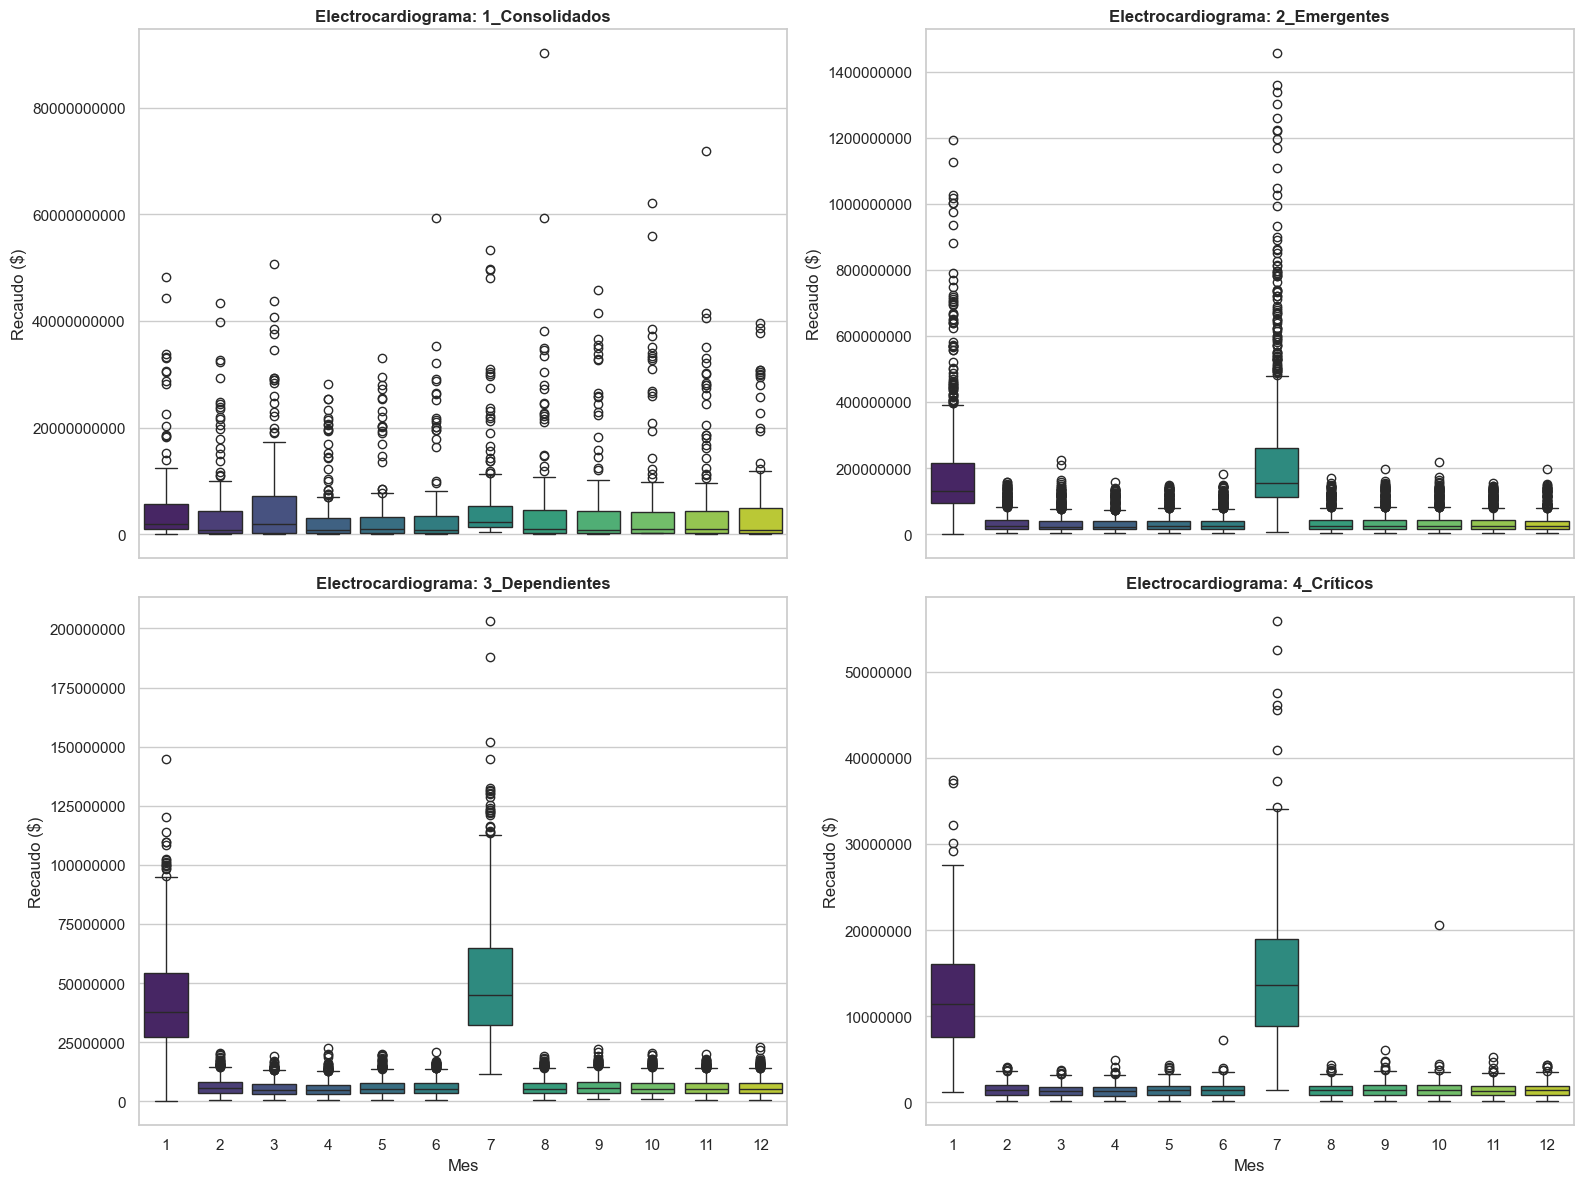

In [4]:
panel['Mes'] = panel['Fecha'].dt.month
tipologias = sorted(panel['Tipologia'].dropna().unique())
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True)
for i, tipo in enumerate(tipologias):
    ax = axes.flatten()[i]
    sns.boxplot(data=panel[panel['Tipologia']==tipo], x='Mes', y='Recaudo', ax=ax, palette='viridis')
    ax.set_title(f'Electrocardiograma: {tipo}', fontweight='bold')
    ax.set_ylabel('Recaudo ($)')
    ax.ticklabel_format(style='plain', axis='y')
plt.tight_layout(); plt.show()


## 4. Correlación Cruzada (Hipótesis del Rezago)

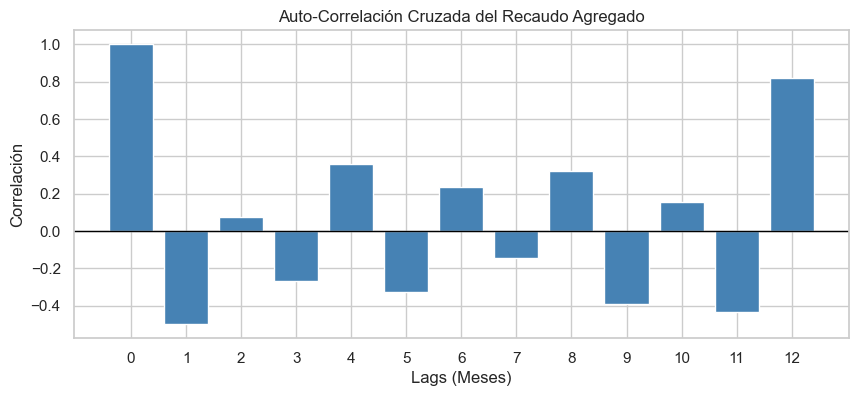

Lag 1: -0.500 | Lag 12: 0.821


In [5]:
serie_total = panel.groupby('Fecha')['Recaudo'].sum().sort_index()
serie_diff = serie_total.diff().dropna()
corr_cruza = ccf(serie_diff.values, serie_diff.values)[:13]
plt.figure(figsize=(10, 4))
plt.bar(range(13), corr_cruza, color='steelblue')
plt.axhline(0, color='black', lw=1)
plt.title('Auto-Correlación Cruzada del Recaudo Agregado')
plt.xlabel('Lags (Meses)'); plt.ylabel('Correlación')
plt.xticks(range(13)); plt.show()
print(f"Lag 1: {corr_cruza[1]:.3f} | Lag 12: {corr_cruza[12]:.3f}")
